<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/DAG_to_Hypergraph_to_Power_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and Config

In [1]:
from dag2laguerre import *
import networkx as nx

# Testing PartitionTreeBuilder and RecursivePowerDiagram

In [2]:
sample_dag = nx.DiGraph()
sample_dag.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 8),
    (3, 6),
    (6, 7),
    (5, 8)
])

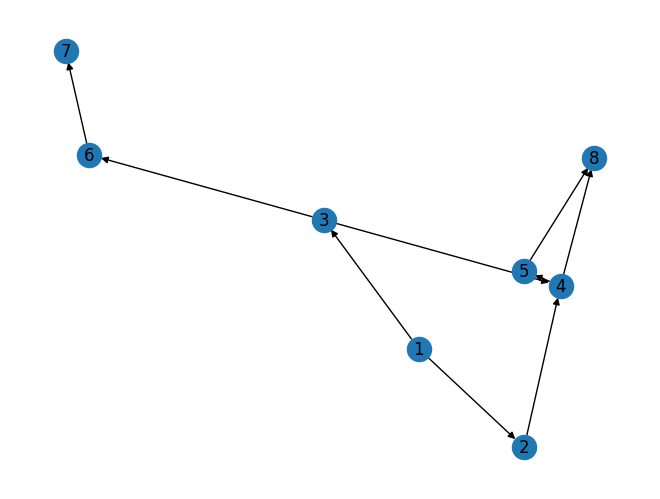

In [3]:
import matplotlib.pyplot as plt

nx.draw(sample_dag, with_labels=True)

In [4]:
sample_partition_tree = PartitionTreeBuilder(sample_dag)
partitions = sample_partition_tree.partition_tree
hye_labels = sample_partition_tree.descendant_hye_node_map

def dict_to_str(d, tabs=0):
  offset = '  '*tabs
  string = ""
  if isinstance(d, dict):
    string += "[\n"
    for k, v in d.items():
      string += f"{offset}{k}: {dict_to_str(v, tabs+1) if len(v) > 0 else None}\n"
    string += f"{offset}]"
    return string
  else:
    return d

print(dict_to_str(partitions))

[
frozenset({1, 2}): None
frozenset({3, 4, 5, 6, 7, 8}): [
  frozenset({8, 4, 5}): [
    frozenset({8, 5}): [
      frozenset({5}): None
      frozenset({8}): None
      ]
    frozenset({4}): None
    ]
  frozenset({3, 6, 7}): [
    frozenset({6}): None
    frozenset({7}): None
    ]
  ]
]


In [5]:
print(partitions)

{frozenset({1, 2}): {}, frozenset({3, 4, 5, 6, 7, 8}): {frozenset({8, 4, 5}): {frozenset({8, 5}): {frozenset({5}): {}, frozenset({8}): {}}, frozenset({4}): {}}, frozenset({3, 6, 7}): {frozenset({6}): {}, frozenset({7}): {}}}}


# Helpers

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, FrozenSet, Hashable, Iterable, List, Mapping, Tuple, Optional

import math
import random

import numpy as np
import networkx as nx
from shapely.geometry import Point, Polygon, LineString, box
from shapely.ops import split, nearest_points


# ----------------------------
# Geometry helpers
# ----------------------------

def _poly_bounds_pad(p: Polygon, pad_factor: float = 10.0) -> Tuple[float, float, float, float]:
    """Return expanded bounds (minx, miny, maxx, maxy) around polygon."""
    minx, miny, maxx, maxy = p.bounds
    dx = max(maxx - minx, 1e-9)
    dy = max(maxy - miny, 1e-9)
    pad_x = dx * pad_factor
    pad_y = dy * pad_factor
    return minx - pad_x, miny - pad_y, maxx + pad_x, maxy + pad_y


def _halfplane_polygon(
    bounding: Polygon,
    a: float, b: float, c: float,
    keep_leq: bool = True,
) -> Polygon:
    """
    Build a (very large) polygon representing the half-plane:
        a*x + b*y <= c   (if keep_leq)
        a*x + b*y >= c   (otherwise)
    restricted to a large rectangle around `bounding`.

    Returns a polygon (possibly empty).
    """
    # Large rectangular canvas
    minx, miny, maxx, maxy = _poly_bounds_pad(bounding, pad_factor=10.0)
    canvas = box(minx, miny, maxx, maxy)

    # If a and b are both ~0, inequality is either always true or false.
    if abs(a) < 1e-12 and abs(b) < 1e-12:
        ok = (0.0 <= c) if keep_leq else (0.0 >= c)
        return canvas if ok else Polygon()

    # Line a*x + b*y = c. Construct two far points on it within canvas extent.
    # Choose which variable to solve for based on magnitude.
    if abs(b) > abs(a):
        # Solve for y = (c - a*x)/b
        x1, x2 = minx, maxx
        y1 = (c - a * x1) / b
        y2 = (c - a * x2) / b
    else:
        # Solve for x = (c - b*y)/a
        y1, y2 = miny, maxy
        x1 = (c - b * y1) / a
        x2 = (c - b * y2) / a

    cut_line = LineString([(x1, y1), (x2, y2)])

    # Split the canvas by the line; choose the side satisfying inequality.
    try:
        parts = split(canvas, cut_line)
    except Exception:
        # If split fails (degenerate), fallback to whole canvas.
        return canvas

    if len(parts.geoms) == 1:
        # Line didn't intersect canvas; pick based on any point on canvas
        test_pt = Point((minx + maxx) / 2.0, (miny + maxy) / 2.0)
        lhs = a * test_pt.x + b * test_pt.y
        ok = (lhs <= c) if keep_leq else (lhs >= c)
        return canvas if ok else Polygon()

    def satisfies(poly: Polygon) -> bool:
        p = poly.representative_point()
        lhs = a * p.x + b * p.y
        return (lhs <= c + 1e-12) if keep_leq else (lhs >= c - 1e-12)

    good = [g for g in parts.geoms if satisfies(g)]
    if not good:
        return Polygon()

    # Sometimes both parts can satisfy due to tolerance; choose the larger.
    good.sort(key=lambda g: g.area, reverse=True)
    return good[0]


def _clip_to_polygon(candidate: Polygon, boundary: Polygon) -> Polygon:
    """Intersect and clean small topology issues."""
    inter = candidate.intersection(boundary)
    # Clean slivers / self-intersections
    if inter.is_empty:
        return Polygon()
    return inter.buffer(0)


def _random_point_in_polygon(poly: Polygon, rng: random.Random, max_tries: int = 10_000) -> Point:
    minx, miny, maxx, maxy = poly.bounds
    for _ in range(max_tries):
        p = Point(rng.uniform(minx, maxx), rng.uniform(miny, maxy))
        if poly.contains(p):
            return p
    # Fallback: representative point is always inside
    return poly.representative_point()


# ----------------------------
# 1) project_onto_polygon
# ----------------------------

def project_onto_polygon(
    pos: Mapping[Hashable, Tuple[float, float]],
    polygon: Polygon,
) -> Dict[Hashable, Point]:
    """
    Take arbitrary 2D layout coordinates (e.g., from nx.spring_layout) and:
      1) Affine-map them into the polygon's bounding box.
      2) Ensure each point is inside polygon by projecting to the nearest point on polygon.

    Returns: node -> shapely Point (guaranteed within polygon, up to boundary tolerance).
    """
    if not pos:
        return {}

    xs = np.array([v[0] for v in pos.values()], dtype=float)
    ys = np.array([v[1] for v in pos.values()], dtype=float)

    # Avoid divide-by-zero for degenerate layouts.
    x_min, x_max = float(xs.min()), float(xs.max())
    y_min, y_max = float(ys.min()), float(ys.max())
    dx = max(x_max - x_min, 1e-12)
    dy = max(y_max - y_min, 1e-12)

    minx, miny, maxx, maxy = polygon.bounds
    bx = max(maxx - minx, 1e-12)
    by = max(maxy - miny, 1e-12)

    out: Dict[Hashable, Point] = {}
    for k, (x, y) in pos.items():
        # Normalize to [0,1] then scale into bbox
        u = (float(x) - x_min) / dx
        v = (float(y) - y_min) / dy
        px = minx + u * bx
        py = miny + v * by
        p = Point(px, py)

        if polygon.contains(p) or polygon.touches(p):
            out[k] = p
        else:
            # Project to nearest point on the polygon boundary
            nearest = nearest_points(polygon, p)[0]
            out[k] = Point(nearest.x, nearest.y)

    return out


# ----------------------------
# 2) weighted_voronoi (power diagram / additively-weighted Voronoi)
# ----------------------------

def weighted_voronoi(
    sites: Mapping[Hashable, Point],
    bounding_polygon: Polygon,
    weights: Optional[Mapping[Hashable, float]] = None,
) -> Dict[Hashable, Polygon]:
    """
    Compute an additively-weighted Voronoi (a.k.a. power diagram cells):

        cell_i = { x in bounding_polygon :
                   ||x - p_i||^2 - w_i <= ||x - p_j||^2 - w_j, for all j }

    This yields linear half-plane constraints per pair (i,j), so each cell is
    obtained by iteratively clipping the bounding polygon against half-planes.

    Args:
      sites: key -> Point (generator locations)
      bounding_polygon: clipping boundary
      weights: key -> nonnegative (or any real) additive weights. If None, all 0.

    Returns:
      key -> Polygon cell (possibly empty for heavily dominated sites).
    """
    keys = list(sites.keys())
    if not keys:
        return {}

    w = {k: 0.0 for k in keys}
    if weights is not None:
        for k, val in weights.items():
            if k in w:
                w[k] = float(val)

    cells: Dict[Hashable, Polygon] = {}

    for i in keys:
        pi = sites[i]
        wi = w[i]
        # Start from bounding polygon
        cell = bounding_polygon

        # Clip against each other site j
        for j in keys:
            if j == i:
                continue
            pj = sites[j]
            wj = w[j]

            # Inequality:
            # ||x-pi||^2 - wi <= ||x-pj||^2 - wj
            # Expand & cancel ||x||^2:
            # -2 pi·x + ||pi||^2 - wi <= -2 pj·x + ||pj||^2 - wj
            # 2(pj - pi)·x <= ||pj||^2 - wj - (||pi||^2 - wi)
            a = 2.0 * (pj.x - pi.x)
            b = 2.0 * (pj.y - pi.y)
            c = (pj.x * pj.x + pj.y * pj.y - wj) - (pi.x * pi.x + pi.y * pi.y - wi)

            hp = _halfplane_polygon(bounding_polygon, a, b, c, keep_leq=True)
            if hp.is_empty:
                cell = Polygon()
                break

            cell = _clip_to_polygon(cell.intersection(hp), bounding_polygon)
            if cell.is_empty:
                break

        cells[i] = cell

    return cells


# ----------------------------
# 3) lloyd_relaxed_power_diagram
# ----------------------------

def lloyd_relaxed_power_diagram(
    keys: Iterable[Tuple[int, int]],
    bounding_polygon: Polygon,
    *,
    iterations: int = 25,
    weight_steps: int = 20,
    seed: int = 0,
) -> Dict[Tuple[int, int], Polygon]:
    """
    Heuristic "Lloyd-relaxed" partition of `bounding_polygon` into cells whose areas
    roughly match key weights.

    In your pseudocode, `keys` are tuples (component_id, component_size).
    We interpret `component_size` as a target area proportion.

    Algorithm (simple, practical heuristic):
      - Initialize generator points randomly inside polygon (one per key).
      - Initialize additive weights w_i = 0.
      - Repeat `iterations` times:
          1) Build power diagram (weighted_voronoi) with current points & weights.
          2) Move each generator to its cell centroid (Lloyd step).
          3) Adjust weights with a few inner steps so cell areas approach target areas:
                 w_i += alpha * (target_area_i - area_i)
             (Larger w_i tends to enlarge cell_i in the "||x-p||^2 - w" convention.)

    Returns:
      key -> Polygon cell
    """
    keys = list(keys)
    if not keys:
        return {}

    rng = random.Random(seed)

    # Target areas proportional to size
    sizes = np.array([max(int(k[1]), 1) for k in keys], dtype=float)
    total_area = float(bounding_polygon.area)
    target_areas = {k: total_area * (sizes[idx] / float(sizes.sum())) for idx, k in enumerate(keys)}

    # Initialize sites randomly within polygon
    sites: Dict[Tuple[int, int], Point] = {k: _random_point_in_polygon(bounding_polygon, rng) for k in keys}
    weights: Dict[Tuple[int, int], float] = {k: 0.0 for k in keys}

    # A safe-ish step size based on polygon scale
    minx, miny, maxx, maxy = bounding_polygon.bounds
    scale = max(maxx - minx, maxy - miny, 1e-6)
    alpha = (scale * scale) * 0.05  # heuristic

    for _ in range(iterations):
        # Inner weight tuning steps
        for _ws in range(weight_steps):
            cells = weighted_voronoi(sites, bounding_polygon, weights=weights)

            # Update weights to correct area mismatch
            for k, cell in cells.items():
                area = float(cell.area) if (cell and not cell.is_empty) else 0.0
                err = target_areas[k] - area
                weights[k] += alpha * (err / max(total_area, 1e-12))

        # Lloyd centroid move
        cells = weighted_voronoi(sites, bounding_polygon, weights=weights)
        for k, cell in cells.items():
            if cell is None or cell.is_empty:
                # If a cell vanished, re-seed the site
                sites[k] = _random_point_in_polygon(bounding_polygon, rng)
                continue

            c = cell.centroid
            # Keep inside boundary (centroid should be inside, but be robust)
            if bounding_polygon.contains(c) or bounding_polygon.touches(c):
                sites[k] = c
            else:
                sites[k] = nearest_points(bounding_polygon, c)[0]

    # Final cells
    return weighted_voronoi(sites, bounding_polygon, weights=weights)

In [ ]:
from __future__ import annotations

from typing import Dict, Hashable, Mapping
import numpy as np
from shapely.geometry import Point, Polygon


def area_matching_weights(
    sites: Dict[Hashable, Point],
    bounding_polygon: Polygon,
    *,
    target_mass: Dict[Hashable, float],
    iters: int = 25,
    step: float = 0.3,
    w_init: float = 0.0,
    w_clip: float | None = None,
) -> Dict[Hashable, float]:
    """
    Compute additive power-distance weights w_i so that weighted_voronoi(sites, ..., weights=w)
    yields cell areas roughly proportional to `target_mass`.

    Intended use (matches your pseudocode comment):
        target_mass[hye] = len(component_map[hye])
        # or any other "mass" proxy; only ratios matter

        w = area_matching_weights(c_i_pos_pts, p_i, target_mass=target_mass)
        p_i_pd = weighted_voronoi(c_i_pos_pts, bounding_polygon=p_i, weights=w)

    Notes:
      - Uses the convention in weighted_voronoi:
            power(x,i) = ||x - p_i||^2 - w_i
        so increasing w_i tends to *expand* cell_i.
      - This is a simple fixed-point / gradient-style update; it’s not guaranteed optimal,
        but works well as a small helper.
    """
    keys = list(sites.keys())
    if not keys:
        return {}

    # normalize masses -> target areas
    mass = np.array([float(target_mass.get(k, 0.0)) for k in keys], dtype=float)
    if np.all(mass <= 0):
        mass = np.ones(len(keys), dtype=float)

    total_area = float(bounding_polygon.area)
    tgt = {k: total_area * (mass[i] / float(mass.sum())) for i, k in enumerate(keys)}

    # step scaled by polygon size (so default step works across coordinate scales)
    minx, miny, maxx, maxy = bounding_polygon.bounds
    scale2 = max(maxx - minx, maxy - miny, 1e-6) ** 2
    lr = float(step) * scale2

    w: Dict[Hashable, float] = {k: float(w_init) for k in keys}

    for _ in range(int(iters)):
        cells = weighted_voronoi(sites, bounding_polygon, weights=w)

        for k in keys:
            area = float(cells[k].area) if (cells.get(k) and not cells[k].is_empty) else 0.0
            err = tgt[k] - area  # positive => want bigger cell => increase w_k
            w[k] += lr * (err / max(total_area, 1e-12))

            if w_clip is not None:
                w[k] = float(np.clip(w[k], -w_clip, w_clip))

    return w

In [ ]:
# G is a nx.DiGraph whose nodes are FrozenSets
def recursive_build_power_diagram(G: nx.DiGraph, bounding_polygon : Polygon) -> Dict[FrozenSet, Polygon]:
      roots: List[FrozenSet] = [n for n in G.nodes() if G.in_degree(n) == 0]
      H = nx.Graph()
      for a in roots: 
        for b in roots:
          anb = a.intersection(b)

          if a != b and anb:
            H.add_edges_from([
                (a - anb, anb),
                (b - anb, anb)
            ])

      component_map: Dict[Tuple[int, int], Set[FrozenSet]] = {
        (i, len(set().union(*c))): c
        for i, c in enumerate(H.connected_components())
      }

      pd_polygons: Dict[Tuple[int, int], Polygon] = lloyd_relaxed_power_diagram( 
        component_map.keys(), 
        bounding_polygon
      )

      I = dict()
      for c_i, p_i in pd_polygons.items():
        c_i_pos = nx.spring_layout(H.subgraph(component_map[c_i])) 
        c_i_pos_pts: Dict[FrozenSet, Point] = project_onto_polygon(c_i_pos, polygon=p_i)
        
        # adjust power distance weights to approximate area = len(component_map[q]) / np.sum(np.array([len(q) for q in component_map[c_i]]))
        target_mass = {hye: len(component_map[hye]) for hye in component_map[c_i]}
        w = area_matching_weights(c_i_pos_pts, p_i, target_mass=target_mass, iters=30, step=0.25, w_clip=5.0)
        p_i_pd: Dict[FrozenSet, Polygon] = weighted_voronoi(c_i_pos_pts, bounding_polygon=p_i, weights=w)
        I.update(p_i_pd)
      
      # get subgraphs  of G for only partitioned hyperedges
      G_subgraphs = {
        hye_i: G.subgraph(hye_i)
        for hye_i in I.keys()
      }
      
      child_pds: Dict[FrozenSet, Polygon] = dict()
      for hye, hye_polygon in I.items():
        child_pds.update(recursive_build_power_diagram(G_subgraphs[hye], hye_polygon))
        I.update(child_pds)
      return I

# Test This implementation

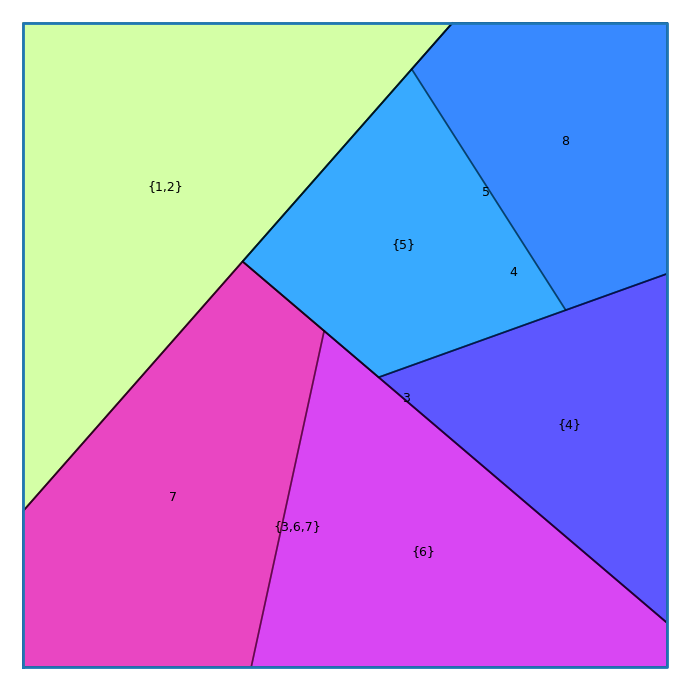

In [6]:
RecursivePowerDiagram(hierarchy=partitions, label_map=hye_labels).show(labels=True, set_labels=True)